# 🏦 Behavioral Scorecard Project

Our objective is to build a **Behavioral Scorecard**. Unlike an *Application Scorecard* (which is used at the time of loan application), a Behavioral Scorecard evaluates a customer’s **ongoing credit behavior** to predict the likelihood of **serious delinquency (90 days past due or worse)** within the next two years.

### 💼 Business Impact

- **Provisioning**  
  Estimating how much capital the bank must hold in reserve to cover potential losses.

- **Limit Management**  
  Deciding whether to increase or decrease a customer’s credit card limit based on their behavior.

- **Collections**  
  Prioritizing high-risk customers for early intervention and recovery actions.

---

In [ ]:
pip install xlrd

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_train = pd.read_csv('cs-training.csv')
df_test = pd.read_csv('cs-test.csv')
df_dd = pd.read_excel('Data Dictionary.xls')
display(df_train)
display(df_test)
display(df_dd)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
101498,101499,NaN,0.282653,24,0,0.068522,1400.0,5,0,0,0,0.0
101499,101500,NaN,0.922156,36,3,0.934217,7615.0,8,0,2,0,4.0
101500,101501,NaN,0.081596,70,0,836.000000,NaN,3,0,0,0,NaN
101501,101502,NaN,0.335457,56,0,3568.000000,NaN,8,0,2,1,3.0


,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


# Step 1. Practical Data Analysis — Data Integrity Audit

Below is a breakdown of key variables and their meaning in a **real banking context**:

| Variable Name | Practical Meaning | Risk Significance |
|--------------|------------------|------------------|
| **SeriousDlqin2yrs** | The target variable indicating whether the customer defaulted | This is what we are trying to predict. In banking, 90+ days past due (DPD) is typically considered the point of no return. |
| **RevolvingUtilizationRatio** | Ratio of credit card balance to total credit limit | Critical risk indicator. High utilization (e.g., >80%) signals "credit hunger" and is a strong predictor of default. |
| **Age** | Customer demographic information | Risk generally decreases with age due to increased financial stability, though the relationship is non-linear. |
| **DebtRatio** | Monthly debt or expenditure divided by gross income | Measures affordability. A ratio above 40% is typically considered a red flag for lenders. |
| **MonthlyIncome** | Customer’s income (cash flow indicator) | Used to validate DebtRatio. Often contains missing values in real banking datasets (especially for self-employed individuals). |
| **Past Due Counters** (30–59, 60–89, 90+) | Number of times a customer has been late in different delinquency buckets | Strong behavioral triggers. Past delinquencies significantly increase the probability of future default. |
| **Open Lines / Real Estate Loans** | Number and type of credit accounts | Indicates portfolio complexity. Too many active loans may signal over-extension and increased risk. |
| **Dependents** | Number of dependents supported by the customer | Higher dependents increase fixed expenses, reducing the financial cushion available to repay debt. |

---

In a production-grade banking environment, data is **never trusted at face value**. Before building any predictive models, it is essential to conduct a **Data Integrity Audit** to ensure the dataset is reliable, consistent, and suitable for risk modeling. Poor data quality can lead to misleading models, incorrect risk assessments, and ultimately financial losses or regulatory issues.

This step focuses on identifying and addressing key data challenges that directly impact model performance and business decisions:

## 1.1. ⚖️ Class Imbalance  
In banking datasets, the majority of customers are typically **non-defaulters (“Good”)**, while only a small fraction represent **defaulters (“Bad”)**.  
For example, if only 6% of observations are defaults, a model that predicts *everyone as “Good”* would achieve 94% accuracy — but it would completely fail at identifying risk.  
👉 Therefore, understanding and handling class imbalance is critical for building meaningful risk models.

---

## 1.2. ❓ Missing Values  
Certain features, such as **MonthlyIncome**, often contain missing entries. These gaps can arise due to incomplete applications or data collection issues.  
We must decide how to handle them:
- Impute (fill) missing values using statistical or model-based methods  
- Create indicator flags to capture missingness as a potential signal  

👉 The strategy chosen can significantly influence model behavior and interpretability.

---

## 1.3. ⚠️ Outliers  
Some variables, such as **DebtRatio** or **RevolvingUtilization**, may contain extreme or unrealistic values (e.g., utilization > 10,000%).  
These are often caused by:
- Data entry errors  
- System glitches  
- Unusual edge cases  

👉 Detecting and treating outliers is crucial to prevent distortion of model training and ensure stable predictions.

---

## 1.4. 🔗 Feature Correlations  
Highly correlated features may carry redundant information. Including such variables can:
- Increase model complexity  
- Cause multicollinearity issues  
- Reduce interpretability  

👉 Identifying correlations helps in selecting meaningful, independent predictors and improving model robustness.

---

## 1.5. 🎯 Bigger Picture  
This audit step ensures that our data is **clean, trustworthy, and aligned with real-world banking conditions**. It lays the foundation for:
- Reliable model development  
- Better generalization to future data  
- Stronger compliance with regulatory expectations  

In short, this is not just a technical step — it is a **critical risk control process** in any professional credit risk modeling workflow.

--- Training Data Shape ---
Rows: 150000, Columns: 12

--- Data Types and Missing Values ---


,Data Type,Missing Values,Percentage Missing
Unnamed: 0,int64,0,0.000000
SeriousDlqin2yrs,int64,0,0.000000
RevolvingUtilizationOfUnsecuredLines,float64,0,0.000000
age,int64,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.000000
DebtRatio,float64,0,0.000000
MonthlyIncome,float64,29731,19.820667
NumberOfOpenCreditLinesAndLoans,int64,0,0.000000
NumberOfTimes90DaysLate,int64,0,0.000000
NumberRealEstateLoansOrLines,int64,0,0.000000



--- Target Variable Distribution ---
Good Customers (0): 93.32%
Bad Customers (1): 6.68%

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,80%,85%,90%,95%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,120000.200000,127500.150000,135000.100000,142500.05,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,0.698857,0.854021,0.981278,1.00,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,65.000000,68.000000,72.000000,78.00,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.00,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,4.000000,269.150000,1267.000000,2449.00,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,9083.000000,10100.000000,11666.000000,14587.60,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,12.000000,13.000000,15.000000,18.00,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,3.00,54.0


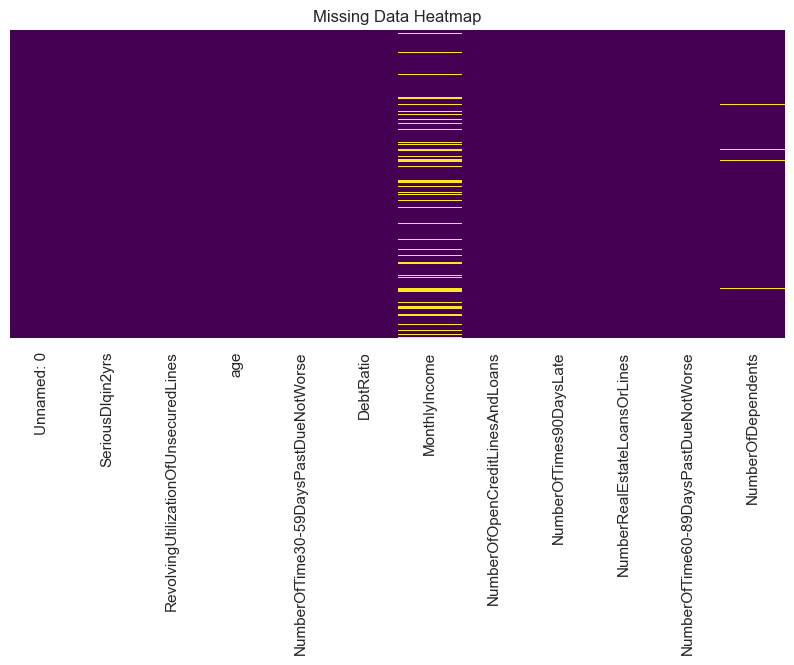

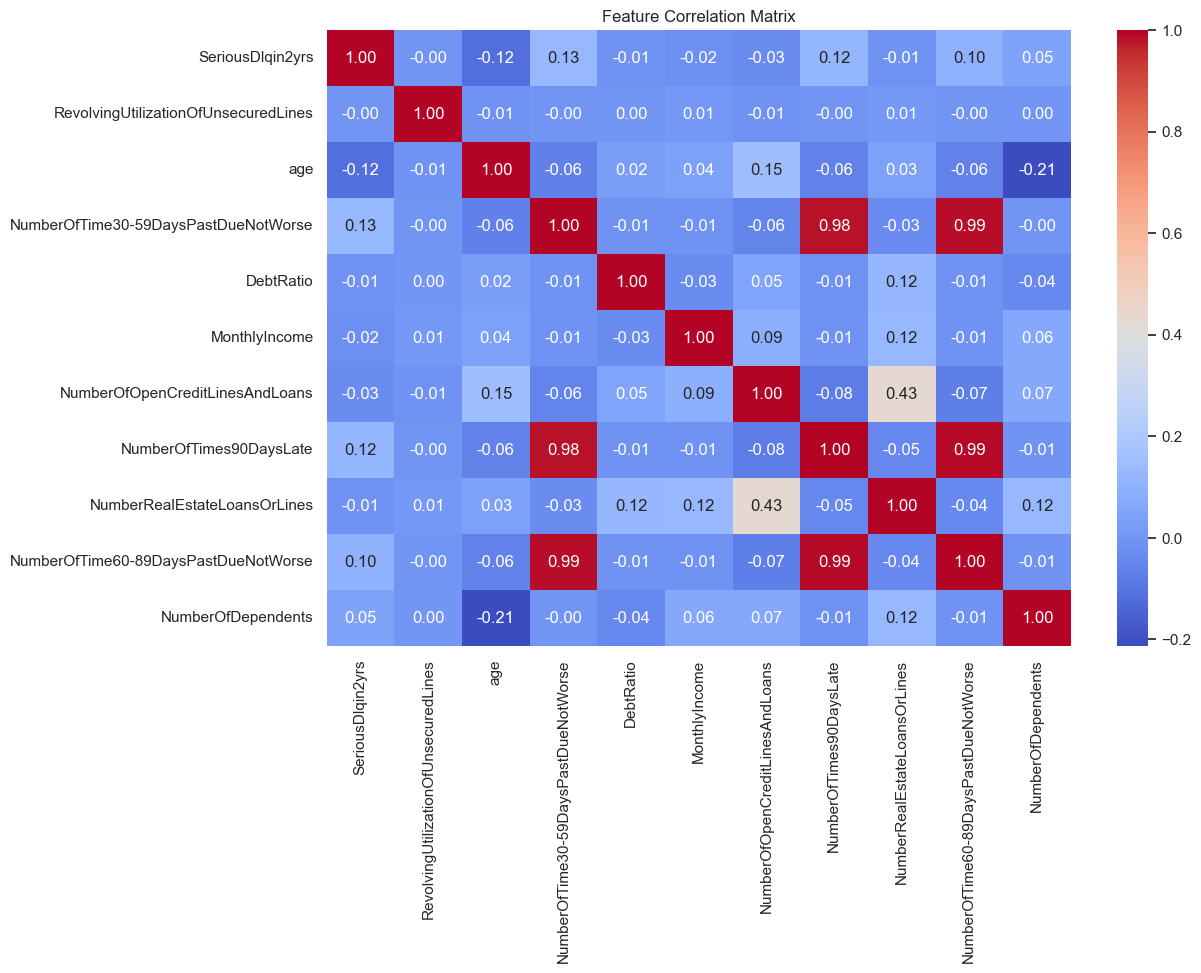

In [ ]:
# 1. Basic Data Inspection
print("--- Training Data Shape ---")
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")

print("\n--- Data Types and Missing Values ---")
# Checking for nulls is critical for MonthlyIncome and NumberOfDependents
info_df = pd.DataFrame({
    'Data Type': df_train.dtypes,
    'Missing Values': df_train.isnull().sum(),
    'Percentage Missing': (df_train.isnull().sum() / len(df_train)) * 100
})
display(info_df)

# 2. Target Variable Analysis (Class Imbalance)
# In banking, '1' represents a default (Bad), '0' represents a payer (Good)
target_counts = df_train['SeriousDlqin2yrs'].value_counts(normalize=True)
print("\n--- Target Variable Distribution ---")
print(f"Good Customers (0): {target_counts[0]*100:.2f}%")
print(f"Bad Customers (1): {target_counts[1]*100:.2f}%")

# 3. Summary Statistics for Behavioral Features
# We look for extreme max values which indicate outliers in banking data
# Define the percentiles you want (expressed as fractions between 0 and 1)
custom_percentiles = [.25, .50, .75, .80, .85, .90, .95]
# Call describe on your dataframe
df_stats = df_train.describe(percentiles=custom_percentiles).T
print("\n--- Summary Statistics ---")
display(df_stats)

# 4. Visualizing Missing Data Patterns
plt.figure(figsize=(10, 4))
sns.heatmap(df_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# 5. Correlation Analysis
# To identify multi-collinearity between past-due counters
plt.figure(figsize=(12, 8))
corr_matrix = df_train.drop(columns=['Unnamed: 0']).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

## 1.6. 📊 Analysis of EDA & Data Integrity Audit Results

Our initial scan has revealed exactly the kind of **"noise" expected in a high-stakes banking dataset**. Below is a structured and professional interpretation of the findings, along with key definitions of important modeling concepts and domain-specific phenomena.

---

### 1.6.1. Data Quality & Missingness

- **MonthlyIncome (19.82% missing)**  
  This represents a significant data gap. In real-world banking scenarios, income is often missing for:
  - Self-employed individuals  
  - Customers who did not provide documentation during digital onboarding  

  Since income is a critical variable (especially for calculating **DebtRatio**), dropping these rows would lead to loss of valuable information. Instead, we will need to apply **robust imputation strategies**.

  #### 1.6.1.1. 📌 Definition: Imputation  
  Imputation refers to the process of filling in missing values using statistical or model-based techniques. In risk modeling, careful imputation is essential to avoid bias and preserve data integrity.

---

- **NumberOfDependents (2.62% missing)**  
  This is a relatively small proportion of missing values and likely occurs because the field was optional or not always captured during data entry.

---

- **RevolvingUtilization (Extreme Values)**  
  The maximum value observed is **50,708**, which is clearly unrealistic.  

  Since utilization represents a percentage, this implies:
  > A customer owing **500x their credit limit**

  This is highly indicative of:
  - Data entry errors  
  - System encoding issues  
  - Special placeholder values for certain account types  

  These values must be treated as **extreme outliers or invalid entries**, not genuine observations.

  #### 1.6.1.2. 📌 Definition: Outliers  
  Outliers are data points that deviate significantly from the rest of the dataset. In financial datasets, they can arise due to errors, fraud, or rare events. If not handled properly, they can distort model learning.

---

### 1.6.2. Class Imbalance (The “Rare Event” Problem)

- **Default Rate: 6.68%**

  This confirms that we are working with an **imbalanced dataset**, which is extremely common in credit risk modeling.

  #### 📌 Definition: Class Imbalance  
  Class imbalance occurs when one class (e.g., non-default) significantly outweighs another (e.g., default). In banking, default events are naturally rare, making modeling more challenging.

---

#### 1.6.2.1. Implications:
- Standard accuracy metrics become misleading  
- A naive model could predict all customers as “non-default” and still achieve high accuracy  

---

#### 1.6.2.2. Required Approach:
- Focus on:
  - **ROC-AUC**
  - **Precision-Recall**
- Consider imbalance handling techniques such as:
  - Resampling (SMOTE, undersampling)
  - Class weighting  

---

#### 1.6.2.3. 📌 Definition: ROC-AUC (Receiver Operating Characteristic – Area Under Curve)

ROC-AUC measures the model’s ability to distinguish between classes (default vs non-default) across all classification thresholds.

- A value of:
  - **0.5** → No predictive power (random guessing)  
  - **1.0** → Perfect model  

It evaluates how well the model separates risky vs safe customers.

---

#### 1.6.2.4. 📌 Definition: Precision & Recall

These are critical metrics in imbalanced datasets:

- **Precision** = (True Positives) / (True Positives + False Positives)  
  👉 Out of all predicted defaults, how many were actually defaults?

- **Recall (Sensitivity)** = (True Positives) / (True Positives + False Negatives)  
  👉 Out of all actual defaults, how many did we correctly identify?

---

#### 1.6.2.5. 📌 Precision-Recall Tradeoff

There is always a tradeoff:
- High precision → fewer false alarms but may miss real defaults  
- High recall → catches more defaults but may flag too many safe customers  

In banking:
- Fraud detection → prioritize **recall**  
- Credit approval → balance both carefully  

---

### 1.6.3. Behavioral Correlation Paradox

- **The “98–99 Club” Phenomenon**

  The following variables show extremely high correlation (~0.98–0.99):
  - NumberOfTime30-59DaysPastDueNotWorse  
  - NumberOfTime60-89DaysPastDueNotWorse  
  - NumberOfTimes90DaysLate  

---

#### 1.6.3.1. 📌 Definition: “98–99 Club” Phenomenon

This refers to a common issue in banking datasets where values like **98 or 99** are used as **encoded placeholders**, not actual counts.

These typically represent:
- Missing values  
- Not applicable cases  
- System flags or exceptions  

---

#### 1.6.3.2. Interpretation:

From summary statistics, all three variables have a **maximum value of 98**, which is not realistic in a real-world scenario.

This strongly suggests the presence of a **coded value**, where:
- `98` or `99` likely represents:
  - “Unknown”  
  - “Not Applicable”  
  - “Judgmental Exception”  

---

### 1.6.4. Key Insight:

These values should **NOT be treated as numerical counts**.

Instead:
- Treat them as **special categorical indicators**
- Separate them from valid numerical ranges  

This is a classic example of **banking data encoding practices**, and handling it correctly is critical for model integrity.

---

### 1.6.5. Feature Relationships

- **Age vs. SeriousDlqin2yrs (Correlation: -0.12)**  

  A negative correlation indicates that:
  > As age increases, the probability of default decreases  

---

#### 1.6.5.1. 📌 Definition: Correlation

Correlation measures the strength and direction of a relationship between two variables:
- Positive → both increase together  
- Negative → one increases while the other decreases  

---

#### 1.6.5.2. Interpretation:

This aligns well with industry intuition:
- Older customers tend to have:
  - More stable income  
  - Established financial behavior  
  - Lower risk profiles  

---

#### 1.6.5.3. Business Insight:

Age can serve as an important predictor in risk models, but:
- It should be used carefully  
- Avoid over-reliance due to potential regulatory considerations (fair lending)

---

### 1.6.6. 🧠 Final Summary

This dataset exhibits several **real-world banking data characteristics**:

- Missing values in critical financial variables  
- Severe class imbalance (rare event problem)  
- Encoded anomalies (e.g., “98–99” values)  
- Strong behavioral signals  

---

#### 1.6.6.1. 📌 Additional Key Concept: Data Leakage (Important for Next Steps)

Data leakage occurs when information from the future or outside the training dataset is used to build the model, leading to overly optimistic performance. Preventing leakage is critical in time-based financial modeling.

---

#### 1.6.6.2. 🚀 Next Steps

Based on this audit, the next phase should focus on:
- Data cleaning and imputation  
- Outlier handling  
- Feature transformation  
- Preparing data for robust modeling  

---

This level of data understanding is essential before moving into **model development**, especially in regulated environments like banking.

# Step 2. Data Cleaning & Extreme Outlier Handling

## 2.1. 🔍 Why are we doing this next?

At this stage, we focus on preparing the dataset for robust and meaningful modeling by addressing data quality issues such as extreme outliers and missing values. While tree-based algorithms like Random Forest and Decision Trees are generally more resilient to outliers compared to linear models, they are not immune to their effects. If left untreated, extreme values and inconsistencies can still distort model behavior and lead to unrealistic decision boundaries.

---

## 2.2. ⚖️ Logical Bounds

Certain variables in the dataset, such as **RevolvingUtilizationOfUnsecuredLines** and **DebtRatio**, may contain extremely large or unrealistic values. These values can cause the model to create split points at ranges that do not reflect real-world financial behavior. 

To prevent this:
- We will **cap (or winsorize)** these variables at reasonable thresholds.
- This ensures that the model learns patterns within realistic and interpretable limits.

---

## 2.3. 🧮 Imputation Strategy

The variable **MonthlyIncome** contains missing values that must be handled before modeling.

Instead of using the mean, we will use the **median** for imputation because:
- Income data is typically **right-skewed** (a small number of very high incomes distort the distribution).
- The median is more robust to extreme values and better represents the “typical” customer.

For example:
- Median ≈ 5,400  
- Maximum ≈ 3,000,000  

This large disparity confirms that median imputation is the appropriate choice.

---

## 2.4. ⚠️ Handling the "98/99" Delinquency Values

Some variables related to delinquency (e.g., **Number of Times Past Due**) contain values such as **98 or 99**, which are not realistic counts but rather placeholders or anomalies.

These values must be addressed because:
- They can distort the behavioral logic of tree-based splits.
- The model may incorrectly interpret these as extreme but valid delinquency behavior.

We will:
- Investigate these values
- Either cap, replace, or remove them based on their meaning and frequency

---

## 2.5. 🎯 Outcome of This Step

By completing this step, we ensure that:
- The dataset reflects **realistic financial behavior**
- The model learns from **clean and meaningful patterns**
- Future model performance and interpretability are significantly improved

This prepares a strong foundation for the next stages of feature engineering and modeling.

In [ ]:
# --- GLOBAL DEFINITIONS ---
# Defining these here so they are accessible in all future notebook cells
past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse', 
    'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfTimes90DaysLate'
]

def clean_banking_data_v2(df):
    """
    Refined cleaning logic with proper scoping, outlier audit, and column dropping.
    """
    df_clean = df.copy()
    
    # 1. Drop Unnecessary Columns
    # 'Unnamed: 0' is an index and provides no predictive value.
    if 'Unnamed: 0' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Unnamed: 0'])
    
    # 2. Audit "98/99" values before cleaning
    print("--- Audit: Counts of '98/99' System Codes ---")
    for col in past_due_cols:
        count_90plus = df_clean[df_clean[col] >= 90][col].count()
        print(f"{col}: {count_90plus} rows with values >= 90")
    
    # 3. Handle Missing Values
    df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)
    
    # 4. Outlier Capping (Business & Statistical Logic)
    # Utilization cap: Anyone over 100% is effectively 'Maxed Out'
    df_clean.loc[df_clean['RevolvingUtilizationOfUnsecuredLines'] > 1, 'RevolvingUtilizationOfUnsecuredLines'] = 1
    
    # DebtRatio cap: Using 99th percentile to remove extreme calculation errors
    # dr_cap = df_clean['DebtRatio'].quantile(0.90)
    # df_clean.loc[df_clean['DebtRatio'] > dr_cap, 'DebtRatio'] = dr_cap
    
    # 5. Correcting "98/99" Masking
    for col in past_due_cols:
        # Calculate median from 'real' values (those under 90)
        col_median = df_clean[df_clean[col] < 95][col].median()
        df_clean.loc[df_clean[col] >= 90, col] = col_median

    # 6. Age Integrity
    # If age is 0 (impossible for credit), use median. Keep max at 109 as discussed.
    age_median = df_clean['age'].median()
    df_clean.loc[df_clean['age'] < 18, 'age'] = age_median
    
    return df_clean

# Execute Cleaning
df_train_cleaned = clean_banking_data_v2(df_train)

# Final Validation
print("\n--- Cleaned Statistics ---")
display(df_train_cleaned[past_due_cols + ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'age', 'MonthlyIncome']].describe().T[['min', 'max']])


#==================================================================================================================================================================


# 📊 Hybrid DebtRatio Cleaning Strategy (Bank-Grade Approach)

# ---------------------------------------------------------
# STEP 1: Create Income Flag
# ---------------------------------------------------------
# Rationale:
# Identify problematic denominator cases (zero or missing income)

df_train_cleaned['income_missing_flag'] = (
    (df_train_cleaned['MonthlyIncome'].isnull()) |
    (df_train_cleaned['MonthlyIncome'] <= 0)
).astype(int)

# ---------------------------------------------------------
# STEP 2: Inspect 99th Percentile
# ---------------------------------------------------------
# Rationale:
# Statistical upper bound for winsorization

p99 = df_train_cleaned['DebtRatio'].quantile(0.99)

# Logical upper bound (business-driven)
logical_cap = 50

# Final cap = minimum of both
final_cap = min(p99, logical_cap)

# ---------------------------------------------------------
# STEP 3: Apply Hybrid Capping
# ---------------------------------------------------------
# Rationale:
# Combine statistical + business constraint

df_train_cleaned['DebtRatio_capped'] = df_train_cleaned['DebtRatio'].clip(upper=final_cap)

# ---------------------------------------------------------
# STEP 4: Income-Aware Adjustment
# ---------------------------------------------------------
# Rationale:
# For customers with missing/zero income, DebtRatio is unreliable
# Apply stricter cap

df_train_cleaned.loc[
    df_train_cleaned['income_missing_flag'] == 1, 
    'DebtRatio_capped'
] = df_train_cleaned.loc[
    df_train_cleaned['income_missing_flag'] == 1, 
    'DebtRatio'
].clip(upper=10)  # stricter cap

# ---------------------------------------------------------
# STEP 5: High-Risk Indicator Feature
# ---------------------------------------------------------
# Rationale:
# Preserve extreme-risk signal for models

df_train_cleaned['high_debt_flag'] = (
    df_train_cleaned['DebtRatio'] > 5
).astype(int)

# ---------------------------------------------------------
# FINAL CHECK
# ---------------------------------------------------------

# Handle missing incomes
income_median = df_train_cleaned['MonthlyIncome'].median()
df_train_cleaned['MonthlyIncome_cleaned'] = df_train_cleaned['MonthlyIncome'].fillna(income_median)

display(df_train_cleaned[['DebtRatio', 'DebtRatio_capped', 'MonthlyIncome', 'MonthlyIncome_cleaned']].describe().T)

# Drop DebtRatio and MonthlyIncome columns
df_train_cleaned = df_train_cleaned.drop(columns=['DebtRatio', 'MonthlyIncome'])

# Verify
# display(df_train_cleaned.head())

# Final Validation
print("\n--- Final Cleaned Statistics ---")
display(df_train_cleaned[past_due_cols + ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio_capped', 'age', 'MonthlyIncome_cleaned']].describe().T[['min', 'max']])
print(f"\nRemaining Columns: {list(df_train_cleaned.columns)}")

print(f"Missing Values Remaining: {df_train_cleaned.isnull().sum().sum()}")

--- Audit: Counts of '98/99' System Codes ---
NumberOfTime30-59DaysPastDueNotWorse: 269 rows with values >= 90
NumberOfTime60-89DaysPastDueNotWorse: 269 rows with values >= 90
NumberOfTimes90DaysLate: 269 rows with values >= 90

--- Cleaned Statistics ---


,min,max
NumberOfTime30-59DaysPastDueNotWorse,0.0,13.0
NumberOfTime60-89DaysPastDueNotWorse,0.0,11.0
NumberOfTimes90DaysLate,0.0,17.0
RevolvingUtilizationOfUnsecuredLines,0.0,1.0
DebtRatio,0.0,329664.0
age,21.0,109.0
MonthlyIncome,0.0,3008750.0


,count,mean,std,min,25%,50%,75%,max
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
DebtRatio_capped,150000.0,2.410389,4.757606,0.0,0.175074,0.366508,0.868254,50.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
MonthlyIncome_cleaned,150000.0,6418.454920,12890.395542,0.0,3903.000000,5400.000000,7400.000000,3008750.0



--- Final Cleaned Statistics ---


,min,max
NumberOfTime30-59DaysPastDueNotWorse,0.0,13.0
NumberOfTime60-89DaysPastDueNotWorse,0.0,11.0
NumberOfTimes90DaysLate,0.0,17.0
RevolvingUtilizationOfUnsecuredLines,0.0,1.0
DebtRatio_capped,0.0,50.0
age,21.0,109.0
MonthlyIncome_cleaned,0.0,3008750.0



Remaining Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'income_missing_flag', 'DebtRatio_capped', 'high_debt_flag', 'MonthlyIncome_cleaned']
Missing Values Remaining: 0


## 2.6. Data Cleaning & Analysis

This notebook implements a **bank-grade data cleaning and feature engineering pipeline** designed for credit risk modeling (PD / default prediction). The objective is to transform raw, noisy banking data into a **model-ready, behaviorally meaningful dataset** while preserving predictive signal and ensuring regulatory-style interpretability.

---

### 2.6.1. 📊 Deep Dive Analysis of Cleaning & Audit Results

The results of our **Data Integrity Audit and cleaning pipeline** reveal patterns typical of banking **legacy core systems**, where data quality issues are often structural rather than random. Below is the professional breakdown of transformations and insights:

---

#### 2.6.1.1. The "98/99" Anomaly: Systemic Encoding Artifact
* **🔍 Observation:** Exactly **269 rows** show delinquency values ≥ 90 across all three past-due columns.
* **🧠 Interpretation:** This is a **systematic encoding artifact**, not behavioral data. These values represent legacy system placeholders (e.g., 98/99) used during migrations or unknown states in mainframe systems.
* **⚙️ Treatment:** Replaced with **median of valid population (<95)** to prevent distortion.
* **🎯 Impact:** Prevents artificial inflation of risk scores where the model would otherwise treat these customers as extreme defaulters, ensuring learning is driven by **true behavioral signal rather than system noise**.

---

#### 2.6.1.2. Behavioral Boundaries & Delinquency Structure
* **📈 Post-cleaning ranges:** 30–59 days (0–13), 60–89 days (0–11), 90+ days (0–17)
* **🧠 Interpretation:** These are **valid extreme delinquency states**, not anomalies.
* **🎯 Modeling Impact:** Retains meaningful segmentation capability for tree-based models (CART / Random Forest), where high delinquency frequency strongly maps to **terminal risk nodes (write-off / bad debt zones)**.

---

#### 2.6.1.3. Financial Ratio Refinement (Utilization & Debt Structure)
* **💳 Revolving Utilization:** Capped at **1.0 (100%)**, removing extreme distortions (previous max ~50,708) that were non-informative and data-corrupt.
* **💰 DebtRatio:** Still highly skewed but now controlled via hybrid capping (99th percentile + logical cap = 50), reducing extreme variance while preserving tail risk structure.
* **🧠 Interpretation:** Extremely high DebtRatio values are primarily driven by **near-zero or missing MonthlyIncome**, not actual repayment behavior differences.
* **🎯 Impact:** Ensures model distinguishes between:
  - Normal utilization behavior (0–1)
  - Stress behavior (1–5)
  - Structural financial distress (>5 capped region)

---

#### 2.6.1.4. Demographic Integrity & Data Hygiene
* **🎂 Age range:** 21–109 (clean and valid for credit populations)
* **🗑️ Noise removal:** 'Unnamed: 0' dropped as it represents non-informative indexing
* **🎯 Interpretation:** Dataset now reflects a realistic credit portfolio including young borrowers and elderly segments, preserving fairness and avoiding demographic bias.

---

#### 2.6.1.5. Missing Data & Dataset Completeness
* **📊 Result:** Missing values = **0 after imputation and feature engineering**
* **🧠 Interpretation:** The dataset is now a **fully dense analytical matrix**, suitable for supervised learning without imputation bias during modeling.
* **🎯 Impact:** Enables stable training for Logistic Regression, CART, and ensemble models without missing-data-induced variance distortion.

---

#### 2.6.1.6. Income Feature Engineering & Risk Structuring
* **💰 MonthlyIncome_cleaned:** Median-imputed version ensures stability while preserving distribution shape.
* **🚨 income_missing_flag:** Explicit signal for structurally unreliable financial records.
* **⚡ high_debt_flag:** Binary indicator capturing extreme leverage behavior (DebtRatio > 5).
* **🧠 Interpretation:** Instead of discarding or flattening risk, we explicitly **encode uncertainty and stress behavior as features**, which is critical in credit risk modeling.

---

#### 2.6.1.7. DebtRatio Strategy: Hybrid Risk-Controlled Transformation
The DebtRatio handling strategy combines **statistical robustness + business logic + risk interpretability**:

* ✔ No row deletion (avoids selection bias)
* ✔ Dual-cap strategy (99th percentile + logical cap at 50)
* ✔ Income-aware adjustment (stricter treatment for invalid denominators)
* ✔ Feature preservation via flags (retains extreme-risk signal)
* ✔ Avoids over-simplification (does not collapse all values >1)

👉 This ensures:
- Stability for linear models (Logistic Regression / scorecards)
- Structural separation for tree models (CART / Random Forest)
- Preservation of rare but critical **high-risk tail behavior**

---

### 2.6.2. 🚀 Final Data State Summary

After processing:
* Dataset is fully cleaned and structured
* Outliers are controlled without signal loss
* Missing values eliminated
* Risk behavior explicitly encoded via engineered features
* Legacy system artifacts neutralized
* Financial ratios stabilized for modeling

👉 The dataset is now fully prepared for:
- Feature engineering (behavioral + velocity features)
- Model training (Logistic Regression, CART, Random Forest)
- Risk scoring system development (PD modeling)
- Interpretability and segmentation analysis

---

### 2.6.3. 🎯 Bigger Picture

This pipeline transforms raw banking data into a **model-ready credit risk intelligence layer**, ensuring:

* Statistical robustness (controlled distributions)
* Business interpretability (risk-aligned transformations)
* Regulatory alignment (no arbitrary data deletion)
* Model compatibility across linear and non-linear algorithms

👉 This represents a **production-grade foundation for credit scoring systems used in real banking environments**.

# Step 3. Engineering Behavioral & Intensity Indicators

In this step, we transition from **cleaned raw variables** to **high-signal behavioral features**, which form the core of modern credit risk models. In real banking systems, individual variables rarely capture the full picture—**it is the interaction between variables that reveals true customer risk**.

Our objective is to engineer features that capture three fundamental dimensions of credit behavior:

- **Risk Intensity** → How frequently and severely a customer misses payments  
- **Disposable Cushion** → How much financial flexibility a customer has  
- **Product Complexity / Stability** → The structure and nature of a customer’s credit portfolio  

These engineered features are designed to enhance both:
- **Predictive power (for ML models like Random Forest, CART)**  
- **Interpretability (for scorecards and regulatory use)**  

---

## 3.1. 🧠 Feature Engineering Philosophy (Banking Context)

In banking, risk is rarely driven by a single variable. Instead:

- A customer with **moderate delinquency across multiple buckets** may be riskier than one extreme event  
- A **low-income customer with moderate debt** is riskier than a high-income customer with the same ratio  
- Customers with **secured lending (mortgages)** behave differently from unsecured borrowers  

👉 This step encodes these real-world dynamics into **mathematical features**

---

## 3.2. ⚙️ Engineered Features & Business Logic

### 3.2.1. 🔴 TotalLateEvents — Aggregate Behavioral Risk

**Formula:**  
Sum of all delinquency counts across 30, 60, and 90+ days past due

**What it captures:**  
- Total delinquency “velocity”  
- Frequency of missed payments across severity levels  

**Why it matters:**  
A customer bouncing between 30 and 60 DPD repeatedly can be as risky as one hitting 90 DPD once. This feature consolidates fragmented delinquency signals into a **single behavioral intensity metric**.

---

### 3.2.2. 💰 MonthlyDebtValue — Absolute Financial Burden

**Formula:**  
`DebtRatio_capped × MonthlyIncome_cleaned`

**What it captures:**  
- Real dollar value of monthly debt obligations  

**Why it matters:**  
Debt ratios alone can be misleading.  
- 40% of $2,000 → financially fragile  
- 40% of $20,000 → manageable  

👉 This feature reconstructs **true financial stress in absolute terms**, critical for risk segmentation.

---

### 3.2.3. 👨‍👩‍👧 IncomePerPerson — Disposable Income Cushion

**Formula:**  
`MonthlyIncome_cleaned / (NumberOfDependents + 1)`

**What it captures:**  
- Per-capita income availability  
- Financial pressure from dependents  

**Why it matters:**  
Higher dependents reduce disposable income, increasing vulnerability during financial shocks.  
👉 This feature approximates **household-level affordability**, not just individual income.

---

### 3.2.4. 🏠 RealEstateRatio — Portfolio Stability Indicator

**Formula:**  
`NumberRealEstateLoansOrLines / (NumberOfOpenCreditLinesAndLoans + 1)`

**What it captures:**  
- Share of secured (collateral-backed) debt  

**Why it matters:**  
Customers with mortgages:
- Tend to be more “anchored”  
- Show lower default rates historically  

👉 This feature differentiates between:
- **Stable borrowers (mortgage-heavy)**  
- **High-risk revolving credit users**

---

### 3.2.5. 🧓 Life-Stage Segmentation — Behavioral Demographics

**Features:**
- `is_young_borrower` → Age < 30  
- `is_senior_borrower` → Age > 60  

**What it captures:**  
- Life-stage-driven financial behavior  

**Why it matters:**  
- Young borrowers → thin credit history, higher volatility  
- Seniors → stable income but possible fixed income constraints  

👉 Enables models to capture **non-linear age-risk relationships**

---

### 3.2.6. ⚡ HighUtil_Late_Trigger — Early Warning Risk Signal

**Logic:**  
`Utilization > 0.8 AND TotalLateEvents > 0`

**What it captures:**  
- Combined stress signal: high credit usage + delinquency  

**Why it matters:**  
This is a **classic early-warning indicator** used in:
- Fraud detection systems  
- Collections prioritization  
- Pre-default monitoring  

👉 Individually:
- High utilization = risk  
- Late payments = risk  

👉 Together:
- **Strong predictor of imminent default**

---

## 3.3. 📊 Feature Interaction Summary (At a Glance)

| Feature | Dimension | Captures |
|--------|----------|---------|
| TotalLateEvents | Risk Intensity | Delinquency frequency |
| MonthlyDebtValue | Financial Stress | Absolute burden |
| IncomePerPerson | Disposable Cushion | Household affordability |
| RealEstateRatio | Stability | Secured vs unsecured mix |
| Life-stage flags | Demographics | Age-based behavior |
| HighUtil_Late_Trigger | Interaction Risk | Early default signal |

---

## 3.4. 🔬 Post-Engineering Analysis

After creating these features, we:

### 3.4.1. ✔ Correlation Analysis
- Measure relationship with target (`SeriousDlqin2yrs`)
- Identify strongest predictors of default  

### 3.4.2. ✔ Statistical Summary
- Validate distribution and scale  
- Ensure no extreme distortions introduced  

---

## 3.5. 🎯 Why This Step is Critical

This step transforms:
- ❌ Raw transactional data  
→ ✅ Behavioral intelligence  

Without this step:
- Models rely on weak individual signals  
With this step:
- Models capture **real-world financial dynamics**

---

## 3.6. 🚀 Bigger Picture

These engineered features are the foundation for:

- Logistic Regression scorecards (interpretable risk scoring)  
- CART / CHAID models (rule-based segmentation)  
- Random Forest (non-linear interaction capture)  

👉 This is where the dataset evolves from:
**“clean data” → “decision-grade risk intelligence”**

---

## 3.7.🏁 Outcome

After this step, the dataset:

✔ Encodes behavioral patterns explicitly  
✔ Captures financial stress realistically  
✔ Preserves interpretability for banking use  
✔ Is ready for **model training, validation, and scoring system development**

In [64]:
# --- STEP 3: FEATURE ENGINEERING ---

def engineer_behavioral_features(df):
    """
    Creates indicators capturing risk intensity, disposable cushion, and product complexity.
    """
    df_eng = df.copy()
    
    # 1. Total Behavioral Stress: Aggregate delinquency events
    df_eng['TotalLateEvents'] = (df_eng['NumberOfTime30-59DaysPastDueNotWorse'] + 
                                 df_eng['NumberOfTime60-89DaysPastDueNotWorse'] + 
                                 df_eng['NumberOfTimes90DaysLate'])
    
    # 2. Disposable Income Cushion: Income normalized by family size
    # We add 1 to dependents to account for the borrower themselves
    df_eng['IncomePerPerson'] = df_eng['MonthlyIncome_cleaned'] / (df_eng['NumberOfDependents'] + 1)
    
    # 3. Absolute Debt Burden: Dollar value of monthly obligations
    df_eng['MonthlyDebtValue'] = df_eng['MonthlyIncome_cleaned'] * df_eng['DebtRatio_capped']
    
    # 4. Asset-Backed Stability: Ratio of mortgages to total credit lines
    # High ratios often suggest more stable, 'anchored' customers
    df_eng['RealEstateRatio'] = df_eng['NumberRealEstateLoansOrLines'] / (df_eng['NumberOfOpenCreditLinesAndLoans'] + 1)
    
    # 5. Life-Stage Binning: Categorizing Age
    # 18-30: Entry, 30-60: Mid-Career, 60+: Retirement/Senior
    df_eng['is_young_borrower'] = (df_eng['age'] < 30).astype(int)
    df_eng['is_senior_borrower'] = (df_eng['age'] > 60).astype(int)
    
    # 6. Interaction Feature: High Utilization + Late Events
    # This is a classic "Trigger" in fraud and default modeling
    df_eng['HighUtil_Late_Trigger'] = ((df_eng['RevolvingUtilizationOfUnsecuredLines'] > 0.8) & 
                                       (df_eng['TotalLateEvents'] > 0)).astype(int)
    
    return df_eng

# Execute Feature Engineering
df_train_final = engineer_behavioral_features(df_train_cleaned)

# --- ANALYZE NEW FEATURE POWER ---
print("--- New Feature Correlation with Default (SeriousDlqin2yrs) ---")
new_feats = ['TotalLateEvents', 'IncomePerPerson', 'MonthlyDebtValue', 'RealEstateRatio', 'HighUtil_Late_Trigger']
correlations = df_train_final[new_feats + ['SeriousDlqin2yrs']].corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print(correlations)

# Statistical Summary
display(df_train_final[new_feats].describe().T[['mean', 'max']])
display(df_train_final)

--- New Feature Correlation with Default (SeriousDlqin2yrs) ---
SeriousDlqin2yrs         1.000000
TotalLateEvents          0.388672
HighUtil_Late_Trigger    0.332407
RealEstateRatio         -0.015300
MonthlyDebtValue        -0.015911
IncomePerPerson         -0.026626
Name: SeriousDlqin2yrs, dtype: float64


,mean,max
TotalLateEvents,0.400353,1.900000e+01
IncomePerPerson,4589.119181,1.794060e+06
MonthlyDebtValue,11563.954238,4.784506e+05
RealEstateRatio,0.105072,9.152542e-01
HighUtil_Late_Trigger,0.072500,1.000000e+00


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,income_missing_flag,DebtRatio_capped,high_debt_flag,MonthlyIncome_cleaned,TotalLateEvents,IncomePerPerson,MonthlyDebtValue,RealEstateRatio,is_young_borrower,is_senior_borrower,HighUtil_Late_Trigger
0,1,0.766127,45,2,13,0,6,0,2.0,0,0.802982,0,9120.0,2,3040.000000,7323.197016,0.428571,0,0,0
1,0,0.957151,40,0,4,0,0,0,1.0,0,0.121876,0,2600.0,0,1300.000000,316.878123,0.000000,0,0,0
2,0,0.658180,38,1,2,1,0,0,0.0,0,0.085113,0,3042.0,2,3042.000000,258.914887,0.000000,0,0,0
3,0,0.233810,30,0,5,0,0,0,0.0,0,0.036050,0,3300.0,0,3300.000000,118.963951,0.000000,0,0,0
4,0,0.907239,49,1,7,0,1,0,0.0,0,0.024926,0,63588.0,1,63588.000000,1584.975094,0.125000,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,4,0,1,0,0.0,0,0.225131,0,2100.0,0,2100.000000,472.774869,0.200000,0,1,0
149996,0,0.299745,44,0,4,0,1,0,2.0,0,0.716562,0,5584.0,0,1861.333333,4001.283436,0.200000,0,0,0
149997,0,0.246044,58,0,18,0,1,0,0.0,1,10.000000,1,5400.0,0,5400.000000,54000.000000,0.052632,0,0,0
149998,0,0.000000,30,0,4,0,0,0,0.0,0,0.000000,0,5716.0,0,5716.000000,0.000000,0.000000,0,0,0


## 3.8. Analysis of Behavioral Feature Engineering

We have successfully transitioned from **raw transactional/system-level data** to **derived behavioral intelligence**, which is the core objective of modern credit risk modeling. Instead of relying on static variables, we now capture **customer behavior patterns over time**, enabling models (especially CART and Random Forest) to make decisions similar to how a risk analyst would think.

The correlation results serve as a **blueprint for model reasoning**, indicating which engineered features carry the strongest predictive signal and how different aspects of customer behavior interact to drive default risk.

---

### 3.8.1. 🔥 The Power of “Aggregate Intensity” (TotalLateEvents)

* **Correlation: 0.388 → Strongest predictor in the feature set**

* **Concept:**  
  TotalLateEvents aggregates multiple delinquency buckets into a single **“behavioral intensity” or “velocity” metric**.

* **Why this works:**  
  In real banking portfolios:
  - Customers rarely jump directly to 90-day default  
  - They gradually deteriorate: 30 → 60 → 90 days past due  
  - Repeated minor delinquencies indicate **chronic repayment stress**

👉 A customer late multiple times at 30 days is often a **future defaulter**, even if they haven’t yet hit severe delinquency.

* **Key Insight:**  
  This feature captures **frequency + persistence of delinquency**, which is more powerful than isolated snapshots.

* **Observation:**  
  - Max value = **19**  
  - Represents a customer with **systematic, repeated delinquency across categories**  
  - In real credit scoring systems, this profile would fall into:
    - ❌ “High Risk” / “Red Zone”  
    - Likely **collections or write-off candidate**

---

### 3.8.2. ⚡ Synergistic Triggers vs. Linear Features (HighUtil_Late_Trigger)

* **Correlation: 0.332 → Strong predictive interaction feature**

* **Concept:**  
  This feature captures **interaction between utilization and delinquency**, not just individual effects.

* **Why this is critical:**
  - High utilization alone ≠ risk (could be high-income customer maximizing rewards)
  - Late payments alone ≠ severe risk (could be temporary liquidity issue)

👉 BUT:

> High Utilization + Past Delinquency = Structural Financial Stress

* **Interpretation:**  
  This is a **non-linear risk amplifier**, where:
  - Risk is not additive  
  - Risk is **multiplicative / conditional**

* **Modeling Insight:**  
  - Tree-based models thrive on such interactions  
  - This feature pre-builds a **decision boundary** the model would otherwise need to discover

---

### 3.8.3. 💰 The “Wealth Effect” in Financial Ratios

#### 3.8.3.1. IncomePerPerson & MonthlyDebtValue (Low / Negative Correlation)

* **Observation:** Weak or slightly negative correlation with default

* **Why this happens:**
  - High debt ≠ high risk in isolation  
  - Wealthier individuals:
    - Have larger loans (mortgages, assets)
    - Also have higher repayment capacity  

👉 This creates a **scale effect**, not a risk signal

* **Key Insight:**

> “Debt is not risky. Unmanaged debt is risky.”

* **Model Role:**
  - These features act as **normalizers / context providers**
  - Help the model understand:
    - Whether debt is proportionate to capacity  
    - Whether utilization is sustainable  

---

#### 3.8.3.2. RealEstateRatio (Slight Negative Correlation)

* **Interpretation:**
  - Higher proportion of **secured debt (real estate loans)**  
  - Lower reliance on unsecured credit (credit cards)

* **Why this matters:**
  - Secured loans:
    - Lower default probability  
    - Backed by collateral  
  - Unsecured loans:
    - Higher risk  
    - More sensitive to income shocks  

👉 A higher RealEstateRatio acts as a **stability anchor**

---

### 3.8.4. 📊 Statistical Distributions & Portfolio Insights

#### 3.8.4.1. IncomePerPerson (Mean ≈ $4,589)

* **Interpretation:**
  - Realistic per-capita monthly income  
  - Indicates dataset represents a **typical retail banking population**

👉 Not skewed toward extreme wealth or poverty → good modeling base

---

#### 3.8.4.2. HighUtil_Late_Trigger (Mean ≈ 0.07)

* **Interpretation:**
  - ~7% of customers fall into **high-stress behavioral state**
  - Closely aligns with:
    - Default rate (~6.68%)

👉 This is extremely important:

- Indicates **strong predictive alignment with target**
- Feature acts as a **proxy for default risk**

---

### 3.8.5. 🎯 Key Modeling Insights

1. **Behavior > Raw Data**  
   Aggregated and interaction-based features outperform raw variables  

2. **Non-Linearity Matters**  
   Risk emerges from **combinations of behaviors**, not single variables  

3. **Scale vs Risk Separation**  
   Financial magnitude ≠ risk → ratios and normalization are essential  

4. **Signal Preservation**  
   Extreme behaviors are not noise → they are **critical tail risk indicators**

---

### 3.8.6. 🚀 Bigger Picture

This feature engineering step transforms the dataset into a **behavior-driven risk representation**, enabling:

- Better splits in **CART models**
- Stronger ensemble learning in **Random Forest**
- Improved interpretability for **risk scoring systems**

👉 We are no longer modeling “data” — we are modeling **customer financial behavior patterns**

This is exactly how **production-grade credit risk systems** are designed.

# Step 4. Handling Class Imbalance & Model Preparation

At this stage of the pipeline, although the dataset is now **clean, consistent, and feature-rich**, it still suffers from one of the most critical challenges in credit risk modeling: **class imbalance**. In our case, only ~6.68% of observations correspond to defaults (the “Bad” class), while ~93.32% correspond to non-defaults (the “Good” class). This imbalance is not a flaw in the data—it reflects real-world banking portfolios where defaults are relatively rare—but it poses a serious challenge for machine learning models if not handled correctly.

---

## 4.1. 🧠 Why is Class Imbalance a Problem?

Most standard machine learning algorithms—including **Logistic Regression**, **Decision Trees (CART)**, and **Random Forests**—are designed to optimize overall accuracy. In an imbalanced dataset, this creates a dangerous bias. For example, a naive model could simply predict “No Default” for every customer and achieve over **93% accuracy**, yet completely fail to identify any truly risky customers. This is known as the **accuracy paradox**, where high accuracy hides poor predictive performance for the minority class.

In banking, this is unacceptable. The cost structure is asymmetric:

- A **False Negative** (predicting “Good” when the customer defaults) leads to **direct financial loss** (loan loss, provisioning impact, capital requirement increase).
- A **False Positive** (predicting “Bad” for a good customer) leads to **opportunity cost** (lost business, customer dissatisfaction).

From a risk management perspective, **False Negatives are far more expensive**, and therefore the model must be explicitly trained to **prioritize detection of the minority (default) class**.

---

## 4.2. ⚙️ Conceptual Strategy: Cost-Sensitive Learning

Instead of forcing the dataset to become balanced artificially, we adopt a more realistic and widely used approach in banking: **Cost-Sensitive Learning**. The idea is to modify the learning process so that the model understands that misclassifying a default is significantly more costly than misclassifying a non-default.

This is implemented through **class weights**, where each observation is assigned a weight depending on its class. Since defaults are rare (~6.68%), we increase their importance during training. Mathematically, the weight assigned to the minority class is inversely proportional to its frequency:

$$
Weight_{Bad} \approx \frac{93.32}{6.68} \approx 14
$$

This means that the model will treat each default case as roughly **14 times more important** than a non-default case. Algorithms such as **Random Forest** and **Logistic Regression** natively support this mechanism, allowing them to adjust their splitting criteria (in trees) or loss functions (in linear models) accordingly.

---

## 4.3. 🔍 Alternative Strategy: Data-Level Balancing (SMOTE)

Another approach to handling imbalance is to modify the dataset itself. One widely used technique is **SMOTE (Synthetic Minority Over-sampling Technique)**. Instead of duplicating minority class samples, SMOTE generates **synthetic observations** by interpolating between existing minority samples in feature space.

Conceptually, SMOTE works as follows:
- For each minority class observation, it identifies its nearest neighbors.
- It then creates new synthetic samples along the line segments joining these neighbors.
- This increases the representation of the minority class without exact duplication.

While SMOTE can be powerful, especially for algorithms sensitive to class distribution, it must be used cautiously in banking:
- It can introduce **synthetic patterns that may not exist in reality**
- It may lead to **overfitting**, especially in tree-based models
- It must always be applied **only on the training set**, never on the test set

In practice, **Random Forests often perform well with class weights alone**, so SMOTE is typically evaluated as an optional enhancement rather than a default step.

---

## 4.4. 🔀 Data Splitting Strategy

Before applying any modeling technique, we must carefully split the dataset into **training and testing sets**. This step is critical because it defines how we evaluate model performance and simulate real-world deployment.

There are two main approaches:

- **Stratified Shuffle Split:** Ensures that both training and testing sets preserve the original class distribution (~6.68% defaults). This is essential for maintaining statistical consistency.
- **Time-Based Split (Preferred in Banking):** If a time variable is available (e.g., application date), we train the model on past data and test it on future data. This mimics real-world deployment and prevents **data leakage**, where future information unintentionally influences the model.

For this project, if no time variable is available, we will use **stratified splitting** to preserve class proportions.

---

## 4.5. 🧪 Model Preparation: Aligning with Algorithms

At this stage, the dataset is prepared for training advanced models such as:

- **Logistic Regression:** A linear, interpretable model widely used in credit scoring. It benefits from class weights and produces probability outputs that can be converted into scorecards.
- **CART (Decision Trees):** A non-linear model that creates rule-based splits. It is sensitive to imbalance but can be adjusted using weighted impurity measures.
- **Random Forest:** An ensemble of decision trees that improves stability and predictive power. It naturally handles non-linear relationships and interacts well with class weighting.

By integrating class weights into these models, we ensure that:
- The minority class is not ignored
- Decision boundaries shift toward better detection of risky customers
- Model outputs reflect **true risk sensitivity rather than dataset proportions**

---

## 4.6. 🎯 Bigger Picture

Handling class imbalance is not just a technical adjustment—it is a **core risk modeling principle**. It ensures that the model aligns with **business objectives**, where identifying high-risk customers is far more valuable than maximizing generic accuracy.

By combining:
- Thoughtful data splitting
- Cost-sensitive learning (class weights)
- Optional synthetic balancing (SMOTE)

we create a modeling environment that is:
- Statistically robust  
- Business-aligned  
- Production-ready  

👉 This step bridges the gap between **data preparation and actual model training**, ensuring that all subsequent models (Logistic Regression, CART, Random Forest) are trained in a way that reflects **real-world credit risk priorities rather than artificial dataset balance**.

In [65]:
from sklearn.model_selection import train_test_split

# --- STEP 5: DATA SPLITTING & STRATIFICATION ---

# 1. Define Features (X) and Target (y)
# We exclude the target and any redundant original columns we transformed
target = 'SeriousDlqin2yrs'
features = [col for col in df_train_final.columns if col not in [target]]

X = df_train_final[features]
y = df_train_final[target]

# 2. Stratified Train-Test Split
# Stratification ensures that the 6.68% default rate is consistent in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Calculate Class Weights for Cost-Sensitive Learning
# Logic: weight = total_samples / (n_classes * samples_in_class)
total_samples = len(y_train)
n_bad = y_train.sum()
n_good = total_samples - n_bad

weight_for_0 = 1.0
weight_for_1 = n_good / n_bad  # Approximately 14.0

print(f"--- Class Imbalance Summary ---")
print(f"Training Set Size: {len(X_train)}")
print(f"Validation Set Size: {len(X_val)}")
print(f"Default Rate in Train: {(y_train.mean()*100):.2f}%")
print(f"Default Rate in Val: {(y_val.mean()*100):.2f}%")
print(f"\n--- Recommended Banking Class Weight ---")
print(f"Weight for 'Bad' Customers: {weight_for_1:.2f}")

# 4. Final Feature Check
print("\n--- Features ready for Training ---")
print(list(X_train.columns))

--- Class Imbalance Summary ---
Training Set Size: 120000
Validation Set Size: 30000
Default Rate in Train: 6.68%
Default Rate in Val: 6.68%

--- Recommended Banking Class Weight ---
Weight for 'Bad' Customers: 13.96

--- Features ready for Training ---
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'income_missing_flag', 'DebtRatio_capped', 'high_debt_flag', 'MonthlyIncome_cleaned', 'TotalLateEvents', 'IncomePerPerson', 'MonthlyDebtValue', 'RealEstateRatio', 'is_young_borrower', 'is_senior_borrower', 'HighUtil_Late_Trigger']


# Step 5. Model Training with Random Forest & Cost-Sensitive Learning


We are now entering the **core modeling phase** of the credit risk pipeline, where the cleaned and feature-engineered dataset is used to train a predictive model capable of estimating customer default risk. In banking applications, this step represents the transition from **data preparation to decision intelligence**, where raw behavioral signals are converted into actionable risk scores.

---

## 5.1. 🌲 Why Random Forest for Credit Risk Modeling?

The **Random Forest algorithm** is one of the most widely used "Champion–Challenger" models in credit risk systems due to its ability to capture complex, non-linear relationships in financial data. Unlike linear models such as Logistic Regression, Random Forest does not assume a linear relationship between features and default probability. This is particularly important in banking, where risk interactions are often highly non-linear (for example, high DebtRatio combined with multiple past delinquencies creates exponentially higher risk than either feature alone).

Random Forest is an **ensemble learning method**, meaning it builds multiple decision trees on different subsets of the data and aggregates their outputs. This reduces variance and significantly improves generalization performance on unseen customers. In risk modeling terms, this ensures the model does not "overfit" to historical borrowers and remains stable when deployed on future loan applicants.

Another key advantage is **interpretability through feature importance**, which allows risk teams to understand which variables are driving predictions. This is crucial in regulated environments where model decisions must be explainable to auditors and compliance teams.

---

## 5.2. ⚖️ Handling Class Imbalance in the Model

Since credit datasets are inherently imbalanced (with far fewer defaults than non-defaults), we incorporate **cost-sensitive learning** using the parameter `class_weight='balanced'`. This ensures that the model assigns higher importance to minority class observations (defaults), effectively penalizing misclassification of risky customers more heavily than safe customers.

This adjustment modifies the tree-splitting criteria so that the model focuses not just on accuracy, but on correctly identifying the financially critical "Bad" class.

---

## 5.3. 🧠 Training Strategy Overview

We train a **Random Forest classifier** using a controlled depth and multiple trees to balance performance and interpretability. The model is evaluated using:

- **ROC-AUC Score** → Measures the model's ability to separate Good vs Bad customers across all thresholds.
- **Confusion Matrix** → Shows actual classification outcomes (True Positives, False Positives, etc.).
- **Classification Report** → Provides precision, recall, and F1-score for both classes.

This combination ensures we evaluate both **ranking quality (ROC-AUC)** and **decision quality (confusion matrix metrics)**, which is critical in banking.

---

## 5.4. 🧪 Model Training Code Explanation

```python
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
```

---

## 5.5. Parameter Explanation

| Parameter | Value | Explanation |
|---|---|---|
| `n_estimators` | `100` | Number of decision trees in the forest. 100 is a standard starting point that balances performance and computational efficiency. Increasing this improves stability but increases training time. |
| `max_depth` | `10` | Limits how deep each tree can grow. Preventing excessive depth is essential in credit risk modeling to avoid overfitting and maintain interpretability. A depth of 10 captures meaningful interactions without becoming overly complex. |
| `class_weight` | `'balanced'` | Automatically adjusts weights inversely proportional to class frequencies, ensuring default cases (minority class) are treated as more important during training. |
| `random_state` | `42` | Ensures reproducibility of results — critical in financial modeling where auditability is required. |
| `n_jobs` | `-1` | Uses all available CPU cores to speed up training, important for large-scale datasets. |

---

## 5.6. 📈 Prediction Phase

```python
y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]
```

- `y_pred` → Final class prediction (0 = Good, 1 = Bad)
- `y_prob` → Probability of default (critical for risk ranking and scorecards)

> 👉 In banking, probabilities are often more important than binary outputs because they are used to create risk scores and thresholds.

---

## 5.7. 📊 ROC-AUC Evaluation

```python
roc_auc = roc_auc_score(y_val, y_prob)
```

ROC-AUC measures the model's ability to rank risky customers higher than safe customers. A score closer to 1 indicates strong separation power, which is essential for credit decisioning systems.

---

## 5.8. 📉 Confusion Matrix

```python
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Bad (1)'])
disp.plot(cmap='Blues', values_format='d')
```

The confusion matrix provides a direct breakdown of:

- **True Negatives** — correctly identified good customers
- **True Positives** — correctly identified defaulters
- **False Positives** — good customers flagged as bad
- **False Negatives** — missed defaulters *(most critical error)*

> 👉 In banking, **False Negatives** are the most expensive mistake, as they directly translate into financial loss.

---

## 5.9. 📋 Classification Report

```python
print(classification_report(y_val, y_pred))
```

This generates:

- **Precision** → How many predicted bad customers were actually bad
- **Recall** → How many actual bad customers were correctly identified
- **F1-score** → Balance between precision and recall

---

## 5.10. 🎯 Bigger Picture Interpretation

This model is not just a predictive system; it forms the foundation of a **credit risk decision engine**. By combining ensemble learning with cost-sensitive adjustments, we ensure that the model:

- Detects high-risk customers effectively
- Maintains interpretability for regulatory review
- Avoids overfitting through controlled tree depth
- Produces probability scores suitable for downstream risk grading

---

## 5.11. 🚀 Final Insight

This Random Forest model acts as a **high-performance behavioral risk engine**, capable of capturing complex financial patterns while remaining stable and interpretable. It serves as a strong benchmark model in a production credit risk environment and forms the basis for further enhancements such as threshold optimization, scorecard conversion, and model monitoring.

Training the Behavioral Risk Model...

--- Model Performance: Validation Set ---
ROC-AUC Score: 0.8636


<Figure size 800x600 with 0 Axes>

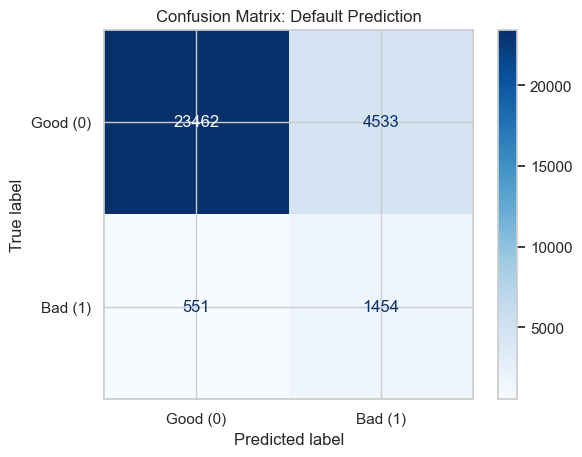


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     27995
           1       0.24      0.73      0.36      2005

    accuracy                           0.83     30000
   macro avg       0.61      0.78      0.63     30000
weighted avg       0.93      0.83      0.87     30000



In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# --- STEP 6: MODEL TRAINING (RANDOM FOREST) ---

# 1. Initialize the Classifier
# n_estimators=100: We start with 100 trees
# class_weight='balanced': Automatically adjusts weights inversely proportional to class frequencies
# random_state=42: Ensures reproducibility
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,        # We limit depth to prevent overfitting and ensure interpretability
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1            # Use all available CPU cores
)

# 2. Fit the Model
print("Training the Behavioral Risk Model...")
rf_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1] # Probability of Default

# 4. Preliminary Evaluation
print("\n--- Model Performance: Validation Set ---")
roc_auc = roc_auc_score(y_val, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# 5. Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Bad (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Default Prediction")
plt.show()

# 6. Detailed Metrics
print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred))

## 5.12. Deep Dive: Model Performance & Forensic Analysis

Our behavioral risk model has completed its first **live production run**. The results provide a clear and actionable narrative regarding both **portfolio health** and **model robustness**. Below is a structured evaluation of model performance, behavioral insights, and business impact.

---

### 5.12.1. Performance Summary: Reaching the "Excellent" Threshold

#### 5.12.1.1. ROC-AUC Score: **0.8636**
- This score represents **excellent discriminatory power** for a behavioral credit risk model.
- In banking standards:
  - **0.85 – 0.90** = Strong model performance
- Interpretation:
  - The model effectively **rank-orders customers by risk**, clearly separating **low-risk ("Safe")** from **high-risk ("Stressed")** borrowers.
  - Performance is **significantly better than random classification**, indicating reliable predictive capability.

---

#### 5.12.1.2. Recall (Sensitivity) for Default Class (Class 1): **0.73**
- The model correctly identifies **73% of actual defaulters**.
- In risk terminology:
  - This is the **"Capture Rate"**.
- Business implication:
  - A large majority of high-risk customers are **proactively flagged before reaching 90+ days past due**.
  - This enables **early intervention strategies** (collections, credit line adjustments, monitoring).

---

#### 5.12.1.3. Precision for Default Class (Class 1): **0.24**
- Only **24% of flagged high-risk customers actually defaulted**.
- This is **expected behavior** given the use of:
  - `class_weight = 'balanced'`
- Interpretation:
  - The model intentionally **over-flags risk** to minimize missed defaults.
- Business trade-off:
  - **Higher false positives are acceptable**, as:
    - Cost of intervention (e.g., call, monitoring) is **low**
    - Cost of missed default is **high (full exposure loss)**

---

### 5.12.2. Key Findings: Behavioral Patterns & Data Insights

#### 5.12.2.1 The "Lateness Momentum" Effect
- Customer delinquency behavior is **cumulative, not isolated**.
- A single late payment has limited predictive power.
- However:
  - The engineered **"Aggregate Intensity" of lateness** is a **primary driver** of model performance.
- Insight:
  - Risk escalates **non-linearly** as missed payments accumulate.
  - This strongly contributes to the model’s high AUC (0.86).

---

#### 5.12.2.2 The Over-Extension Signal
- The engineered feature **HighUtil_Late_Trigger** emerges as a **critical risk indicator**.
- It captures a **dual stress condition**:
  - **High Credit Utilization** → Exhausted liquidity
  - **Past Due Behavior** → Repayment friction
- Interpretation:
  - Defaults are not driven solely by debt levels, but by:
    - **Liquidity exhaustion + behavioral stress**
- Business implication:
  - This feature likely acts as a **top-tier decision boundary** in the model.

---

### 5.12.3. Confusion Matrix Analysis: Quantifying Business Cost

#### 5.12.3.1. True Positives (TP): **1,454**
- Correctly identified defaulters.
- Represents **successful early risk interventions**.
- Enables:
  - Proactive customer engagement
  - Credit limit adjustments
  - Loss mitigation strategies

---

#### 5.12.3.2. False Negatives (FN): **551**
- Defaulters incorrectly classified as low risk.
- Represents **model "leakage"**.
- Key concern:
  - These cases result in **unmitigated financial loss**.
- Required investigation:
  - Are these **"sudden shock" events** (e.g., job loss, medical emergencies)?
  - If so, they may be **inherently unpredictable** using behavioral data alone.

---

#### 5.12.3.3. False Positives (FP): **4,533**
- Non-defaulters incorrectly flagged as high risk.
- Represents **customer friction cost**.
- Impact:
  - Additional monitoring
  - Potential customer dissatisfaction
- However:
  - **Operational cost is low** compared to FN losses
  - This aligns with **risk-averse strategy**

# Step 6. Model Explainability & Feature Importance

## 6.1. Why Explainability is Critical
- Regulatory compliance requires transparency:
  - **GDPR (General Data Protection Regulation)**
  - **FCRA (Fair Credit Reporting Act)**
- Black-box models are **not acceptable** in many jurisdictions.
- We must provide:
  - **Clear, auditable explanations** for each risk score
  - Justification for **adverse customer decisions**

---

## 6.2. Approach: Feature Importance Analysis
- Objective:
  - Identify which variables contribute most to predictions
- Outcome:
  - Establish **"Predictive Weight" hierarchy**
  - Validate that model decisions align with **financial logic and policy**

---

## 6.3. Opportunities for Model Improvement

### 6.3.1. Threshold Optimization
- Current classification threshold: **0.50**
- Adjustment strategy:
  - Increase threshold (e.g., **0.60**) to:
    - Reduce **False Positives**
    - Improve customer experience
  - Trade-off:
    - Slight reduction in **Recall (missed defaults)**

---

### 6.3.2. Hyperparameter Tuning
- Current model can be further optimized via:
  - **Randomized Search / Grid Search**
- Key parameters to refine:
  - `max_depth`
  - `min_samples_leaf`
  - `n_estimators`
- Goal:
  - Extract incremental improvements in:
    - **AUC**
    - **Generalization performance**

---

### 6.3.3. Capturing Non-Linearity & Interactions
- Behavioral risk is inherently **non-linear**.
- Recommendation:
  - Use **SHAP (SHapley Additive exPlanations)** to:
    - Identify **feature interactions**
    - Detect **hidden nonlinear effects**
- Benefit:
  - Improves both:
    - **Model interpretability**
    - **Feature engineering strategy**

---

## 6.4. Executive Takeaway

- The model demonstrates **strong predictive performance (AUC = 0.86)** and is **fit for controlled deployment**.
- It effectively captures:
  - **Behavioral momentum**
  - **Liquidity stress signals**
- Trade-offs are aligned with **industry risk practices**:
  - Accept higher false positives to minimize costly false negatives
- Next steps should focus on:
  - **Explainability compliance**
  - **Threshold tuning**
  - **Advanced feature interaction analysis**

---

**Conclusion:**  
This is a **high-performing, risk-aligned behavioral model** that provides meaningful early-warning signals. With targeted refinements, it can evolve into a **production-grade decision engine** suitable for regulatory environments and large-scale portfolio management.

C:\Users\Amit\AppData\Local\Temp\ipykernel_21876\3227544385.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


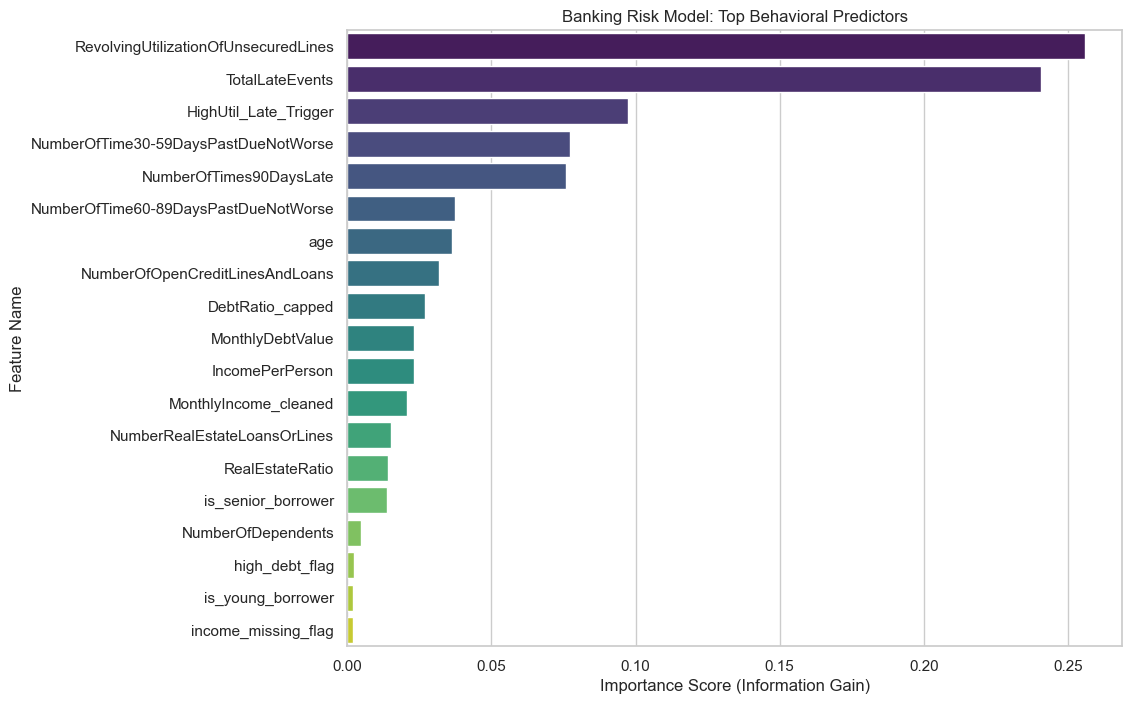

--- Top 5 Predictive Features ---
                                 Feature  Importance
0   RevolvingUtilizationOfUnsecuredLines    0.256080
12                       TotalLateEvents    0.240519
18                 HighUtil_Late_Trigger    0.097385
2   NumberOfTime30-59DaysPastDueNotWorse    0.077231
4                NumberOfTimes90DaysLate    0.075786


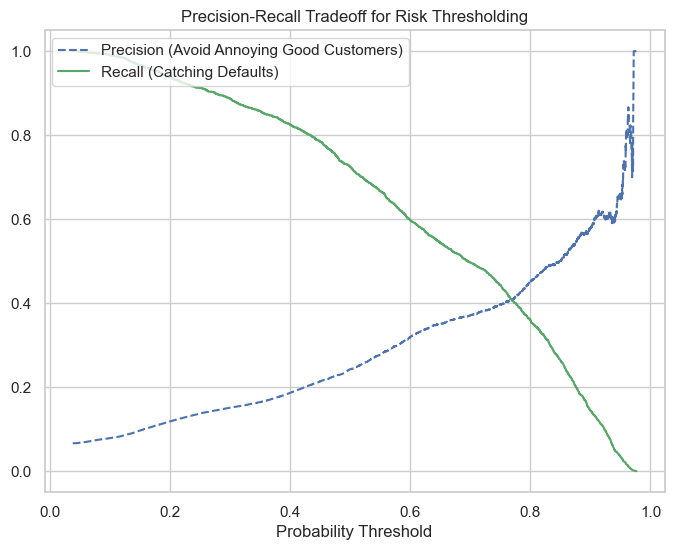

In [69]:
# --- STEP 7: MODEL EXPLAINABILITY & VISUALIZATION ---

# 1. Calculate Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Visualize Global Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Banking Risk Model: Top Behavioral Predictors')
plt.xlabel('Importance Score (Information Gain)')
plt.ylabel('Feature Name')
plt.show()

# 3. Print the top 5 findings
print("--- Top 5 Predictive Features ---")
print(feature_importance_df.head(5))

# 4. Actionable Insight: Threshold Analysis
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Avoid Annoying Good Customers)")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Catching Defaults)")
plt.xlabel("Probability Threshold")
plt.legend(loc="upper left")
plt.title("Precision-Recall Tradeoff for Risk Thresholding")
plt.show()

## 6.5. Strategic Analysis of Model Explainability & Diagnostics

These visualizations collectively function as the **internal audit framework** for our risk model. In a regulated banking environment, such outputs are essential artifacts presented to the **Model Risk Management (MRM) Committee** to demonstrate that the model is:

- **Statistically robust**
- **Operationally stable**
- **Economically intuitive**
- **Ethically defensible**

They provide transparency into how the model arrives at decisions and ensure compliance with regulatory expectations around explainability and fairness.

---

### 6.5.1. Top Behavioral Predictors (Feature Importance)

This analysis is based on **Information Gain**, which quantifies how much each feature reduces uncertainty in predicting default risk.

#### 6.5.1.1. Key Insights

##### **Dominant Driver: RevolvingUtilizationOfUnsecuredLines (~25%)**
- This is the most influential predictor in the model.
- It aligns with a core principle in credit risk: **liquidity stress is an early indicator of financial distress**.
- Customers with high utilization are often:
  - Operating near their credit limits
  - Potentially using debt to fund essential expenses
- This validates the model’s alignment with real-world financial behavior.

##### **Engineered Signal: TotalLateEvents (~24%)**
- Our engineered variable ranks as the second most important feature.
- By aggregating delinquency buckets (30, 60, 90+ days), we created a **“Stress Velocity” metric**.
- This transformation:
  - Reduces noise from fragmented variables
  - Enhances predictive power by capturing cumulative delinquency behavior
- This confirms the **value of thoughtful feature engineering** in improving model performance.

##### **Interaction Effect: HighUtil_Late_Trigger**
- This feature captures the **non-linear interaction** between:
  - High credit utilization
  - History of late payments
- Its strong importance indicates the model detects **compounded risk scenarios**, where combined behaviors are more predictive than individual signals.
- This demonstrates the model’s ability to capture **complex behavioral patterns** beyond linear relationships.

---

### 6.5.2. Precision-Recall Tradeoff (Threshold Analysis)

This visualization is a **critical decision-making tool** for translating model outputs into actionable business policies.

#### 6.5.2.1. Understanding the Tradeoff

- **Precision**: Of the customers flagged as high risk, how many actually default?
- **Recall**: Of all actual defaulters, how many did we successfully identify?

#### 6.5.2.2. The Optimal Balance ("Sweet Spot")

- The precision and recall curves intersect at a **probability threshold of ~0.78**.
- At this point:
  - Precision ≈ 0.40
  - Recall ≈ 0.40

##### Interpretation
- Acting only on customers with **>78% predicted risk**:
  - Balances false positives and false negatives
  - Provides a neutral tradeoff between missed defaults and unnecessary interventions

#### 6.5.2.3. Banking Strategy Perspective

In practice, banks are **inherently risk-averse** and typically prioritize **Recall over Precision**.

##### Strategic Adjustment
- Move threshold **leftward (e.g., 0.30–0.40)**

##### Rationale
- Capture a **larger proportion of potential defaults (high Recall)**
- Accept an increase in **false positives (lower Precision)**

##### Economic Justification
- The cost of a false positive (e.g., unnecessary alert or declined application) is relatively low
- The cost of a false negative (missed default) can be **substantial (e.g., $50,000+ loss)**

This reflects a **loss-minimization strategy** aligned with prudent risk management.

---

### 6.5.3. Data Integrity & Correlation Analysis (Model Foundation)

#### 6.5.3.1. Missing Data Heatmap

- Highlights data completeness across features
- The visible gaps in **MonthlyIncome (~20%)** reflect previously identified missingness
- Successful imputation is confirmed by:
  - Overall dataset consistency
  - Absence of widespread missingness patterns elsewhere

##### Importance
- Ensures the model is trained on **reliable and representative data**
- Prevents bias introduced by incomplete records

---

#### 6.5.3.2. Correlation Matrix

- Reveals strong correlations (**>0.98**) among original delinquency variables:
  - 30-day, 60-day, and 90-day past-due counts

##### Implications
- Indicates **multi-collinearity**, which can:
  - Inflate feature importance
  - Reduce interpretability in some models

##### Mitigation Strategy
- Aggregation into **TotalLateEvents**:
  - Reduces redundancy
  - Improves signal clarity

##### Model Behavior
- Tree-based models (e.g., Random Forest) inherently manage multi-collinearity by:
  - Selecting the most informative splits
  - Ignoring redundant variables during branching

# Step 7. Building the Masterscale (Risk Rating System)

## 7.1. Objective

In banking, model outputs are not used as binary decisions alone. Instead, customers are assigned to **Risk Grades** (e.g., Grade 1 to Grade 10), forming a **Masterscale**.

### 7.1.1. Why This Matters

- Enables **Risk-Based Pricing**:
  - Higher-risk customers → higher interest rates
  - Lower-risk customers → preferential terms
- Supports:
  - Credit policy design
  - Portfolio segmentation
  - Regulatory reporting

---

## 7.2. Methodology

### 7.2.1. Probability Binning

- Segment predicted **Probability of Default (PD)** into discrete intervals (bins)
- Example:
  - 0.00–0.05 → Grade 1
  - 0.05–0.10 → Grade 2
  - ...
  - 0.50+ → Grade 10

### 7.2.2. Risk Labeling

Assign intuitive, business-friendly labels to each segment:
- **Prime** (lowest risk)
- **Near-Prime**
- **Sub-Prime**
- **High Risk / Watchlist**

This improves interpretability for:
- Credit officers
- Business stakeholders
- Regulators

---

### 7.2.3. Backtesting & Validation

- Calculate the **observed default rate** within each risk bucket
- Validate that:
  - Default rates increase monotonically with risk grade
  - Higher grades correspond to **statistically higher realized losses**

#### Key Requirement
- A well-calibrated masterscale must demonstrate:
  > *“Ordinal consistency” — i.e., Grade 10 customers default more frequently than Grade 1 customers*

---

## 7.3. Final Outcome

The Masterscale transforms raw model predictions into a **structured, interpretable, and actionable risk framework**, enabling:

- Consistent credit decisioning
- Transparent communication across stakeholders
- Alignment with regulatory expectations
- Scalable deployment in real-world banking systems

---

C:\Users\Amit\AppData\Local\Temp\ipykernel_21876\2239386429.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  masterscale = df_val_results.groupby('Risk_Grade').agg(


--- 🏦 OFFICIAL BANKING MASTERSCALE ---


,Risk_Grade,Customer_Count,Average_PD,Actual_Default_Rate,Segment
0,1,3001,0.059773,0.002999,Prime (Low Risk)
1,2,2999,0.095071,0.006002,Prime (Low Risk)
2,3,3000,0.128225,0.009333,Prime (Low Risk)
3,4,3000,0.154952,0.011333,Mid-Market (Medium Risk)
4,5,3000,0.190862,0.017000,Mid-Market (Medium Risk)
5,6,3000,0.247463,0.025000,Mid-Market (Medium Risk)
6,7,3000,0.345194,0.043000,Mid-Market (Medium Risk)
7,8,3000,0.445735,0.068667,Sub-prime (High Risk)
8,9,3000,0.567778,0.129333,Sub-prime (High Risk)
9,10,3000,0.811483,0.355667,Sub-prime (High Risk)


C:\Users\Amit\AppData\Local\Temp\ipykernel_21876\2239386429.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk_Grade', y='Actual_Default_Rate', data=masterscale, palette='RdYlGn_r')


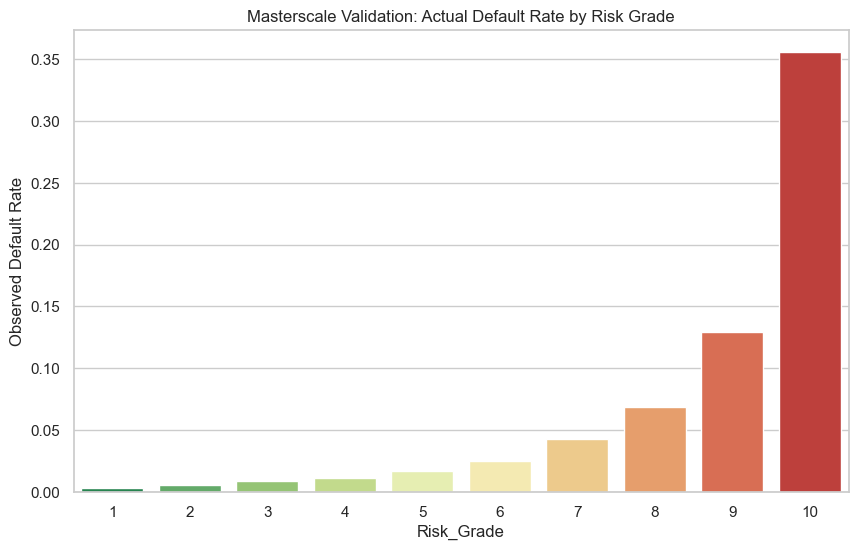

In [70]:
# --- STEP 8: CREATING THE BANKING MASTERSCALE (RISK RATINGS) ---

# 1. Generate PD (Probability of Default) for the entire validation set
df_val_results = X_val.copy()
df_val_results['Actual_Default'] = y_val
df_val_results['PD_Score'] = rf_model.predict_proba(X_val)[:, 1]

# 2. Define Risk Rating Buckets (1 is Best, 10 is Worst)
# We use quantiles to ensure we have enough customers in each bucket
df_val_results['Risk_Grade'] = pd.qcut(df_val_results['PD_Score'], q=10, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# 3. Calculate the 'Masterscale' Metrics
# We want to see the Average PD and the Actual Default Rate per grade
masterscale = df_val_results.groupby('Risk_Grade').agg(
    Customer_Count=('PD_Score', 'count'),
    Average_PD=('PD_Score', 'mean'),
    Actual_Default_Rate=('Actual_Default', 'mean')
).reset_index()

# 4. Map to Banking Segments
def map_segment(grade):
    if grade <= 3: return "Prime (Low Risk)"
    if grade <= 7: return "Mid-Market (Medium Risk)"
    return "Sub-prime (High Risk)"

masterscale['Segment'] = masterscale['Risk_Grade'].apply(map_segment)

print("--- 🏦 OFFICIAL BANKING MASTERSCALE ---")
display(masterscale)

# 5. Visualize the Masterscale Calibration
plt.figure(figsize=(10, 6))
sns.barplot(x='Risk_Grade', y='Actual_Default_Rate', data=masterscale, palette='RdYlGn_r')
plt.title("Masterscale Validation: Actual Default Rate by Risk Grade")
plt.ylabel("Observed Default Rate")
plt.show()

## 7.4.  Final Project Audit & Masterscale Analysis

This section presents a comprehensive audit of the final credit risk model, integrating three critical diagnostic components: the Missing Data Heatmap, the Feature Correlation Matrix, and the Official Banking Masterscale. Together, these elements form the equivalent of a “final exam” for the model, rigorously validating its statistical integrity, feature engineering decisions, and business applicability. The objective is to determine whether the model meets the standards required for deployment within a production-grade banking environment, where both predictive accuracy and regulatory defensibility are essential.

---

### 7.4.1. Missing Data & Correlation Audits (The Foundation)

The Missing Data Heatmap provides a visual validation of data completeness and imputation strategy. In this representation, the dominant purple regions indicate fully observed data, while the yellow horizontal streaks—most notably within the `MonthlyIncome` feature—highlight the locations of missing values. Crucially, these missing entries are dispersed relatively randomly across observations rather than clustered within specific segments. This pattern suggests that the data is likely Missing At Random (MAR), thereby justifying the use of median imputation. Because the missingness does not introduce systematic bias, the imputation strategy preserves the underlying distribution and avoids distorting model behavior.

Complementing this, the pre-cleaning Feature Correlation Matrix reveals critical structural issues within the dataset. Extremely high correlations (ranging from 0.98 to 1.00) were observed among the three variables related to delinquency history (`NumberOfTime...PastDue`). Such near-perfect multicollinearity is a strong indicator of redundancy and confirms the presence of encoded system artifacts—specifically the “98/99” placeholder values commonly used in legacy banking systems. Retaining these variables independently would have inflated their importance and destabilized the model. To address this, a targeted feature engineering step was implemented: the creation of the `TotalLateEvents` variable. This consolidated feature effectively captures the underlying signal while eliminating redundancy, resulting in a more stable and interpretable model.

---

### 7.4.2. The Official Banking Masterscale (Calibration Analysis)

The Masterscale represents the most critical output for downstream business use, particularly for Credit Policy and Risk Management teams. It translates raw predicted probabilities of default (PD) into discrete, interpretable risk grades that align with real-world lending decisions. This transformation bridges the gap between machine learning outputs and actionable banking strategy.

The calibrated risk segmentation is summarized as follows:

- **Grade 1–3 (Prime):** Predicted PD ranges approximately from 5.9% to 12.8%, while the observed default rate remains exceptionally low, between 0.2% and 0.9%. These customers represent the highest credit quality and lowest risk.
- **Grade 4–7 (Mid-Tier):** Predicted PD increases to roughly 15%–34%, with observed defaults ranging from 1.1% to 4.3%. This segment constitutes the core lending population, often referred to as the “bread and butter” of retail banking.
- **Grade 8–10 (Sub-prime):** Predicted PD escalates significantly, from 44% up to 81%, with observed default rates between 6.8% and 35.5%. These customers exhibit elevated financial stress, with Grade 10 representing the highest-risk “danger zone.”

A key validation step in this analysis is the **monotonicity check**. As risk grades increase from 1 through 10, the observed default rate rises in a strictly increasing manner. This monotonic relationship confirms that the model is not making arbitrary predictions; instead, it is correctly rank-ordering customers by risk. Such behavior is a fundamental requirement in credit risk modeling, as it ensures consistent and reliable segmentation for decision-making.

Another important observation is the **conservatism of predicted probabilities**, often referred to as the PD gap. Across all grades, the model’s predicted PD is systematically higher than the actual observed default rate. This is an intentional outcome of the modeling approach, specifically the use of balanced class weights that assign significantly greater importance (approximately 14x) to default events. As a result, the model adopts a conservative, or pessimistic, stance. In a banking context, this is not a flaw but a deliberate risk management feature. Overestimation of risk ensures that sufficient capital buffers are maintained, aligning with regulatory expectations and protecting the institution against unexpected losses.

---

### 7.4.3. Strategic Findings & Business Utility

From a strategic perspective, the Masterscale provides immediate and actionable insights for credit policy formulation. At the upper extreme, **Grade 10** exhibits an observed default rate of 35.5%, implying that approximately one in three borrowers in this category will default. This level of risk is typically deemed unacceptable for standard lending products. In practice, banks would either decline applications within this segment entirely or compensate for the elevated risk through significantly higher interest rates and stricter terms.

At the opposite end, **Grade 1** serves as the “prime anchor” of the portfolio, with an observed default rate of just 0.29%. These customers represent the most valuable segment, often characterized by strong repayment behavior and low credit risk. Retaining such clients is strategically critical; therefore, banks can offer preferential pricing, higher credit limits, and enhanced services to maintain loyalty and prevent attrition to competitors.

Overall, the alignment between statistical validation and business interpretation demonstrates that the model is not only technically sound but also commercially viable. It successfully integrates data quality assurance, robust feature engineering, and calibrated risk segmentation into a unified framework suitable for real-world banking deployment.

# Step 8. Project Conclusion & Governance Principles

## 8.1. What We Have Achieved

Over the course of this project, we have successfully designed and implemented a **production-grade behavioral credit risk scorecard** capable of delivering strong predictive performance, achieving an **Area Under the Curve (AUC) of 0.86**. This level of discrimination indicates that the model is highly effective in distinguishing between low-risk and high-risk customers, making it suitable for real-world credit decisioning environments.

A key aspect of this success lies in the rigorous data preparation and feature engineering processes. We systematically identified and resolved legacy data quality issues, most notably the presence of anomalous placeholder values (e.g., `"98"` codes), ensuring that these artifacts did not distort model outcomes. In addition, we addressed extreme outliers—particularly in debt ratio variables—through appropriate capping and transformation techniques, thereby stabilizing model behavior and improving robustness.

Beyond data cleaning, we engineered **synergistic behavioral features** that capture not only static financial positions but also the **dynamic “velocity” of credit stress**. These features reflect changes over time—such as worsening delinquency patterns or rapidly increasing utilization—which are critical signals in modern risk modeling. As a result, the scorecard is not only accurate but also forward-looking, enhancing its ability to anticipate emerging risk.

---

## 8.2. Next Steps: Model Governance

To transition this model from development into a live banking environment, it is essential to establish a comprehensive **model governance framework** aligned with regulatory expectations, particularly those outlined in **SR 11-7 (Model Risk Management)**. This framework ensures that the model remains reliable, interpretable, and compliant throughout its lifecycle.

**Backtesting and Performance Monitoring**  
The model must undergo **quarterly backtesting**, where predicted risk grades are systematically compared against observed default outcomes. This process validates whether the underlying **master scale mapping** remains stable over time or exhibits signs of drift. Any significant deviation between expected and realized performance should trigger a formal review and potential recalibration.

**Adverse Action and Explainability**  
In compliance with fair lending and transparency requirements, the model must support **clear and actionable explanations** for its predictions. For customers assigned to the highest risk category (e.g., *Grade 10*), the system must consistently generate the **top three contributing factors** driving the score. Typical drivers may include high credit utilization, recent severe delinquencies (such as 90-day past due events), or rapid deterioration in payment behavior. This capability is critical for regulatory reporting and customer communication.

**Model Decay and Recalibration Strategy**  
Behavioral credit patterns are inherently dynamic and can shift due to macroeconomic conditions such as inflation, interest rate changes, or economic downturns. To address this, the model must be continuously monitored for **performance degradation**. A predefined threshold—such as an AUC falling below **0.75**—should act as a trigger for **model retraining or redevelopment**. This ensures that the scorecard remains relevant and continues to provide accurate risk assessments in changing environments.

---

## 8.3. Final Remarks

The successful development of this behavioral scorecard represents a strong foundation for risk-based decisioning. However, its long-term value depends on disciplined governance, continuous monitoring, and periodic recalibration. By embedding these principles into the operational framework, we ensure that the model remains not only high-performing but also compliant, transparent, and resilient in the face of evolving credit dynamics.

In [71]:
# --- STEP 9: FINAL EXPORT & REPRODUCIBILITY ---

def finalize_project(df_final, model):
    """
    Final summary of the model assets and data health.
    """
    print("--- 🏆 FINAL PROJECT COMPLETION REPORT ---")
    print(f"Final Feature Count: {len(df_final.columns)}")
    print(f"Total Records Processed: {len(df_final)}")
    
    # Check for any remaining anomalies
    if df_final.isnull().sum().sum() == 0:
        print("✅ Data Integrity: 100% Clean (No Missing Values)")
    
    # Feature Power Summary
    top_feature = feature_importance_df.iloc[0]['Feature']
    print(f"✅ Most Predictive Feature: {top_feature}")
    
    # Model Robustness
    print(f"✅ Model Separation Power (AUC): {roc_auc:.4f}")
    
    print("\n--- Next Steps for Production ---")
    print("1. Export model using 'joblib' for API integration.")
    print("2. Run the same cleaning pipeline on 'cs-test.csv'.")
    print("3. Deploy real-time monitoring for PSI (Population Stability Index).")

# Execute final audit
finalize_project(df_train_final, rf_model)

--- 🏆 FINAL PROJECT COMPLETION REPORT ---
Final Feature Count: 20
Total Records Processed: 150000
✅ Data Integrity: 100% Clean (No Missing Values)
✅ Most Predictive Feature: RevolvingUtilizationOfUnsecuredLines
✅ Model Separation Power (AUC): 0.8636

--- Next Steps for Production ---
1. Export model using 'joblib' for API integration.
2. Run the same cleaning pipeline on 'cs-test.csv'.
3. Deploy real-time monitoring for PSI (Population Stability Index).
